##### Deterministic Ficticious Play for Normal Form Games

1 1


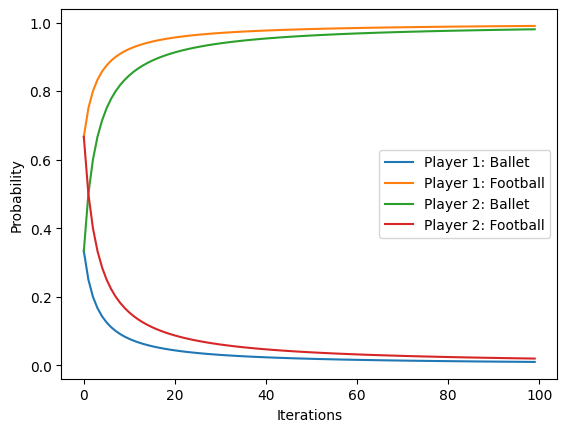

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Define the payoff matrices for Player 1 and Player 2 in Battle of the Sexes
# Rows represent Player 1's actions (B = 0, F = 1), and columns represent Player 2's actions (B = 0, F = 1)
payoff_matrix_p1 = np.array([[2, 0], [0, 1]])  # Payoff for Player 1
payoff_matrix_p2 = np.array([[1, 0], [0, 2]])  # Payoff for Player 2

# Initialize the weight functions (kappa) for both players
def initialize_weights(n_actions):
    return np.ones(n_actions)  # Start with equal weight for each action

# Update the weight function
def update_weights(weights, action_opponent):
    weights[action_opponent] += 1
    return weights

# Normalize the weight function to get belief (mu)
def normalize_weights(weights):
    return weights / np.sum(weights)

# Compute the best response for a player given the opponent's beliefs
def best_response(payoff_matrix, opponent_belief):
    expected_utilities = np.dot(payoff_matrix, opponent_belief)
    return np.argmax(expected_utilities)

# Fictitious play function for deterministic play
def fictitious_play_deterministic(payoff_p1, payoff_p2, num_iters=100):
    n_actions = payoff_p1.shape[0]

    # Initialize weights (kappa) for both players
    weights_p1 = initialize_weights(n_actions)
    weights_p2 = initialize_weights(n_actions)

    # Initialize strategy histories
    history_p1 = np.zeros((num_iters, n_actions))  # Player 1's strategy history
    history_p2 = np.zeros((num_iters, n_actions))  # Player 2's strategy history

    # Initialize action choices (random start)
    action_p1 = np.random.choice(n_actions)
    action_p2 = np.random.choice(n_actions)

    for t in range(num_iters):
        # Update the weight function based on the opponent's last action
        weights_p1 = update_weights(weights_p1, action_p2)
        weights_p2 = update_weights(weights_p2, action_p1)

        # Calculate the beliefs by normalizing the weights
        belief_p1 = normalize_weights(weights_p1)
        belief_p2 = normalize_weights(weights_p2)

        # Store the current belief as the player's strategy
        history_p1[t] = belief_p1
        history_p2[t] = belief_p2

        # Compute deterministic best responses based on the beliefs
        action_p1 = best_response(payoff_p1, belief_p2)
        action_p2 = best_response(payoff_p2, belief_p1)
    print(action_p2, action_p2)
    return history_p1, history_p2

# Run deterministic fictitious play for Battle of the Sexes
num_iters = 100
history_p1, history_p2 = fictitious_play_deterministic(payoff_matrix_p1, payoff_matrix_p2, num_iters)

# Plot the strategy evolution over time
plt.figure()

# Player 1's strategy evolution
plt.plot(history_p1[:, 0], label="Player 1: Ballet")
plt.plot(history_p1[:, 1], label="Player 1: Football")

# Player 2's strategy evolution
plt.plot(history_p2[:, 0], label="Player 2: Ballet")
plt.plot(history_p2[:, 1], label="Player 2: Football")

# Adding labels and legend
plt.xlabel("Iterations")
plt.ylabel("Probability")
plt.legend()
plt.show()

##### Determinisitic Ficticious Play for Mixed Strategies

<Figure size 600x400 with 0 Axes>

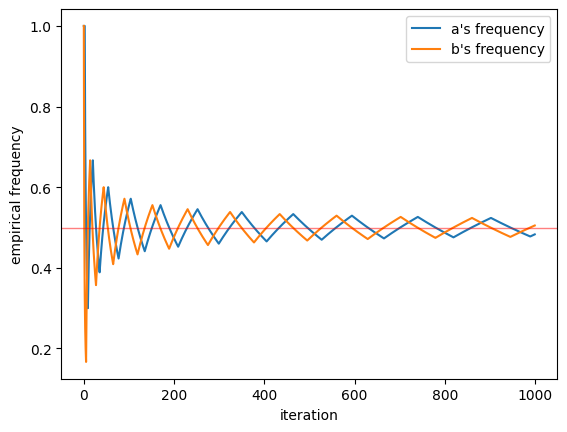

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

n_iter=1000
beliefs=np.array([[1.5,2],[2,1.5]])
history=np.empty((n_iter,2))

def update_beliefs(a,b,beliefs):
    beliefs[1,0]+=1 if a==0 else 0
    beliefs[1,1]+=1 if a==1 else 0
    beliefs[0,0]+=1 if b==0 else 0
    beliefs[0,1]+=1 if b==1 else 0
    return beliefs

for i in range(n_iter):
    a=np.argmax(beliefs[0])
    b=np.argmin(beliefs[1])
    beliefs=update_beliefs(a,b,beliefs)
    history[i]=[a,b]

cumulative=pd.DataFrame(history,columns=["a","b"]).expanding().mean()

plt.figure(figsize=(6,4))
cumulative.plot()
plt.axhline(0.5,alpha=0.5,color="red",lw=1)
plt.xlabel("iteration")
plt.ylabel("empirical frequency")
plt.legend(["a's frequency","b's frequency"])
plt.show()

#### Logit-Stochastic Ficticious Play in Mixed Strategies

<Figure size 600x400 with 0 Axes>

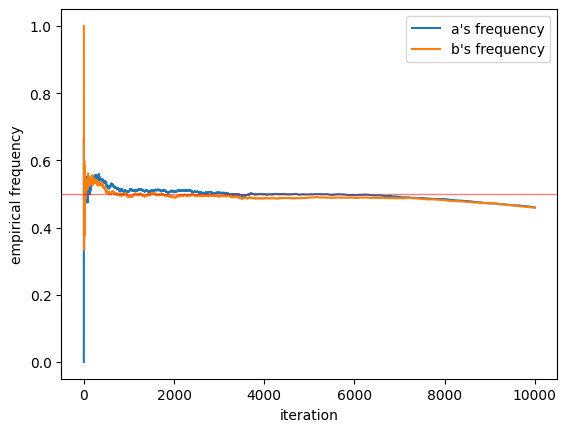

In [61]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

n_iter = 10000
eta = 0.001  # inverse temperature parameter for logit
epsilon_bar = 0.05  # maximum perturbation for stochastic play
beliefs = np.array([[1, 0], [0, 1]])
history = np.empty((n_iter, 2))

def update_beliefs(a, b, beliefs):
    beliefs[1, 0] += 1 if a == 0 else 0
    beliefs[1, 1] += 1 if a == 1 else 0
    beliefs[0, 0] += 1 if b == 0 else 0
    beliefs[0, 1] += 1 if b == 1 else 0
    return beliefs

def logit_choice(payoffs, eta):
    perturbed_payoffs = payoffs + np.random.uniform(0, epsilon_bar, size=payoffs.shape)
    exp_values = np.exp(eta * perturbed_payoffs)
    return exp_values / np.sum(exp_values)

for i in range(n_iter):
    payoff_a = beliefs[0]
    payoff_b = beliefs[1]
    prob_a = logit_choice(payoff_a, eta)
    prob_b = logit_choice(payoff_b, eta)
    a = np.random.choice([0, 1], p=prob_a)
    b = np.random.choice([0, 1], p=prob_b)
    beliefs = update_beliefs(a, b, beliefs)
    history[i] = [a, b]

cumulative = pd.DataFrame(history, columns=["a", "b"]).expanding().mean()
plt.figure(figsize=(6, 4))
cumulative.plot()
plt.axhline(0.5, alpha=0.5, color="red", lw=1)
plt.xlabel("iteration")
plt.ylabel("empirical frequency")
plt.legend(["a's frequency", "b's frequency"])
plt.show()

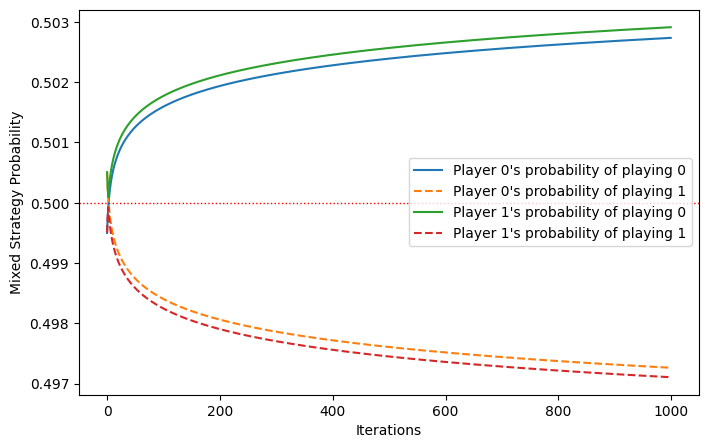

In [67]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

n_iter = 1000
n_players = 2
strategies = [0, 1]  # Two possible strategies, 0 and 1
alpha_init = 0.001
epsilon_init = 0.01

# Initialize strategies for both players (mixed strategies)
# Each row is a player, each column is the probability of choosing 0 or 1
strategy_profile = np.full((n_players, 2), 0.5)

# History to store mixed strategies over time
history = np.empty((n_iter, n_players, 2))

def best_response(strategy_opp, epsilon):
    perturbed_payoff = strategy_opp + np.random.uniform(0, epsilon, size=strategy_opp.shape)
    return np.array([1.0, 0.0]) if perturbed_payoff[0] > perturbed_payoff[1] else np.array([0.0, 1.0])

def update_strategy(pi_i, best_response_i, alpha, M_i):
    return (1 - alpha) * pi_i + alpha * (best_response_i + M_i)

for t in range(n_iter):
    alpha_t = alpha_init / (t + 1)
    epsilon_t = epsilon_init / (t + 1)
    
    for i in range(n_players):
        opponent = (i + 1) % n_players
        best_response_i = best_response(strategy_profile[opponent], epsilon_t)
        M_i_t = np.random.normal(0, epsilon_t, size=2)
        strategy_profile[i] = update_strategy(strategy_profile[i], best_response_i, alpha_t, M_i_t)
    
    history[t] = strategy_profile

# Plot the strategy profile evolution
fig, ax = plt.subplots(figsize=(8, 5))
for i in range(n_players):
    ax.plot(history[:, i, 0], label=f"Player {i}'s probability of playing 0")
    ax.plot(history[:, i, 1], label=f"Player {i}'s probability of playing 1", linestyle="--")

plt.axhline(0.5, color='red', linestyle=':', lw=1)
plt.xlabel("Iterations")
plt.ylabel("Mixed Strategy Probability")
plt.legend()
plt.show()
